## Import libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from sklearn.calibration import CalibrationDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score, 
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


from watermark import watermark

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

print(watermark())


Last updated: 2026-03-29T01:14:22.828241+02:00

Python implementation: CPython
Python version       : 3.12.0
IPython version      : 9.12.0

Compiler    : Clang 14.0.6 
OS          : Darwin
Release     : 25.3.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit



In [2]:
print(watermark(packages="numpy,pandas,seaborn,shap,sklearn"))

numpy  : 2.4.3
pandas : 3.0.1
seaborn: 0.13.2
shap   : 0.51.0
sklearn: 1.8.0



In [3]:
RANDOM_STATE=42

## Load Data

In [4]:
df = pd.read_csv('METABRIC_RNA_Mutation.csv', low_memory=False)
df.shape

(1904, 693)

In [5]:
df['pam50_+_claudin-low_subtype'].value_counts()

pam50_+_claudin-low_subtype
LumA           679
LumB           461
Her2           220
claudin-low    199
Basal          199
Normal         140
NC               6
Name: count, dtype: int64

In [6]:
# We isolate only the patients classified as Luminal A ('LumA').
# This guarantees our model only looks at clinical variance within this "low-risk" group.

df_LumA = df[df['pam50_+_claudin-low_subtype'] == 'LumA'].copy()

In [7]:
df_LumA.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
10,36,85.49,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
13,46,83.02,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
23,68,51.01,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
29,97,78.19,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


## Typical data pre-processing

In [8]:
# We want to predict purely breast cancer mortality (1) vs surviving/other death (0).

df_LumA['target_mortality'] = df_LumA['death_from_cancer'].apply(
    lambda x: 1 if str(x).strip().lower() == 'died of disease' else 0
)

df_LumA['target_mortality'].value_counts()

target_mortality
0    533
1    146
Name: count, dtype: int64

In [9]:
total_luma = len(df_LumA)
died_luma = len(df_LumA[df_LumA['target_mortality'] == 1])
lived_luma = len(df_LumA[df_LumA['target_mortality'] == 0])
mortality_rate = (died_luma / total_luma) * 100

print("Survival Stats:\n------")
print(f"Subset of patients assigned with Luminal A: {total_luma}")
print(f"Patients who LIVED (Expected): {lived_luma}")
print(f"Patients who DIED (The Discordant Group): {died_luma}")
print(f"Discordance Rate: {mortality_rate:.1f}%\n------")

Survival Stats:
------
Subset of patients assigned with Luminal A: 679
Patients who LIVED (Expected): 533
Patients who DIED (The Discordant Group): 146
Discordance Rate: 21.5%
------


In [10]:
# Drop columns that would cause data leakage (like survival_months) or target variables
leakage_cols = ['patient_id', 'overall_survival_months',
                 'overall_survival', 'death_from_cancer', 'target_mortality']

# Automatically select all numeric columns from the isolated Luminal A dataset
numeric_cols = df_LumA.select_dtypes(include=['number']).columns.tolist()

# Filter out the leakage columns
features = [col for col in numeric_cols if col not in leakage_cols]

X = df_LumA[features]
y = df_LumA['target_mortality']

print(f"Shape of newly created dataset: {X.shape}")

Shape of newly created dataset: (679, 500)


In [11]:
# Subset of 'Luminal A' into the two outcomes

LumA_died = df_LumA[df_LumA['target_mortality'] == 1]
LumA_lived = df_LumA[df_LumA['target_mortality'] == 0]

In [12]:
# The features we want to compare

features_to_compare = [
    'nottingham_prognostic_index',
    'tumor_size',
    'neoplasm_histologic_grade',
    'lymph_nodes_examined_positive'
]

for feature in features_to_compare:

    mean_died = LumA_died[feature].mean()
    mean_lived = LumA_lived[feature].mean()
    std_died = LumA_died[feature].std()
    std_lived = LumA_lived[feature].std()
    
    print(f"Examined feature: {feature} (mean ± std):")
    print(f"  -> Patients who DIED : {mean_died:.2f} ± {std_died:.2f}")
    print(f"  -> Patients who LIVED: {mean_lived:.2f} ± {std_lived:.2f}")
    print("-" * 40)

Examined feature: nottingham_prognostic_index (mean ± std):
  -> Patients who DIED : 4.01 ± 1.19
  -> Patients who LIVED: 3.49 ± 1.05
----------------------------------------
Examined feature: tumor_size (mean ± std):
  -> Patients who DIED : 28.17 ± 15.97
  -> Patients who LIVED: 22.64 ± 10.23
----------------------------------------
Examined feature: neoplasm_histologic_grade (mean ± std):
  -> Patients who DIED : 2.29 ± 0.61
  -> Patients who LIVED: 2.02 ± 0.66
----------------------------------------
Examined feature: lymph_nodes_examined_positive (mean ± std):
  -> Patients who DIED : 2.77 ± 4.74
  -> Patients who LIVED: 1.15 ± 2.48
----------------------------------------


In [13]:
# we impute missing numeric values with the median of that specific feature.

missing_values = X.isnull().sum()
print(missing_values[missing_values > 0].to_string())

total_imputed = missing_values.sum()
print(f"\n\nTotal imputed data points: {total_imputed} (out of {X.shape[0] * X.shape[1]} total points)")

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X),
                          columns=X.columns)

neoplasm_histologic_grade     31
mutation_count                 7
tumor_size                     1
tumor_stage                  159


Total imputed data points: 198 (out of 339500 total points)


## Getting prepared for data modeling

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [15]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), 
                              columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), 
                             columns=X_test.columns)

In [16]:
models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=2000, random_state=42),
        {'C': [0.01, 0.1, 1, 10], 'class_weight': [None, 'balanced']}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7], 'class_weight': [None, 'balanced']}
    ),
    'SVM': (
        SVC(probability=True, random_state=42),
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'class_weight': [None, 'balanced']}
    )
}

In [17]:
%%time

best_models = {}
best_auc = 0
winning_model_name = ""
winning_model = None

for name, (model, params) in models.items():
    grid = GridSearchCV(
        model,
        params,
        cv=5,
        scoring={
            "balanced_accuracy": "balanced_accuracy",
            "roc_auc": "roc_auc",
        },
        refit="roc_auc",
        n_jobs=-1
    )
    grid.fit(X_train_scaled, y_train)

    test_proba = grid.predict_proba(X_test_scaled)[:, 1]
    test_pred = grid.predict(X_test_scaled)

    test_auc = roc_auc_score(y_test, test_proba)
    test_bal_acc = balanced_accuracy_score(y_test, test_pred)


    cv_auc = grid.best_score_
    cv_bal_acc = grid.cv_results_["mean_test_balanced_accuracy"][grid.best_index_]

    best_models[name] = grid.best_estimator_
    print(
        f"{name:<20} | CV AUC = {cv_auc:.3f} | CV Bal Acc = {cv_bal_acc:.3f} | "
        f"Test AUC = {test_auc:.3f} | Test Bal Acc = {test_bal_acc:.3f}"
    )

    if test_auc > best_auc:
        best_auc, best_bal_acc = test_auc, test_bal_acc
        winning_model_name = name
        winning_model = grid.best_estimator_

print(f"\n\n🏆 WINNING MODEL: {winning_model_name} (Test AUC: {best_auc:.3f}, Test Bal Acc: {best_bal_acc:.3f})")

Logistic Regression  | CV AUC = 0.694 | CV Bal Acc = 0.614 | Test AUC = 0.628 | Test Bal Acc = 0.587
Random Forest        | CV AUC = 0.679 | CV Bal Acc = 0.557 | Test AUC = 0.682 | Test Bal Acc = 0.615
SVM                  | CV AUC = 0.691 | CV Bal Acc = 0.553 | Test AUC = 0.655 | Test Bal Acc = 0.574


🏆 WINNING MODEL: Random Forest (Test AUC: 0.682, Test Bal Acc: 0.615)
CPU times: user 677 ms, sys: 117 ms, total: 794 ms
Wall time: 7.97 s


## Performance plots

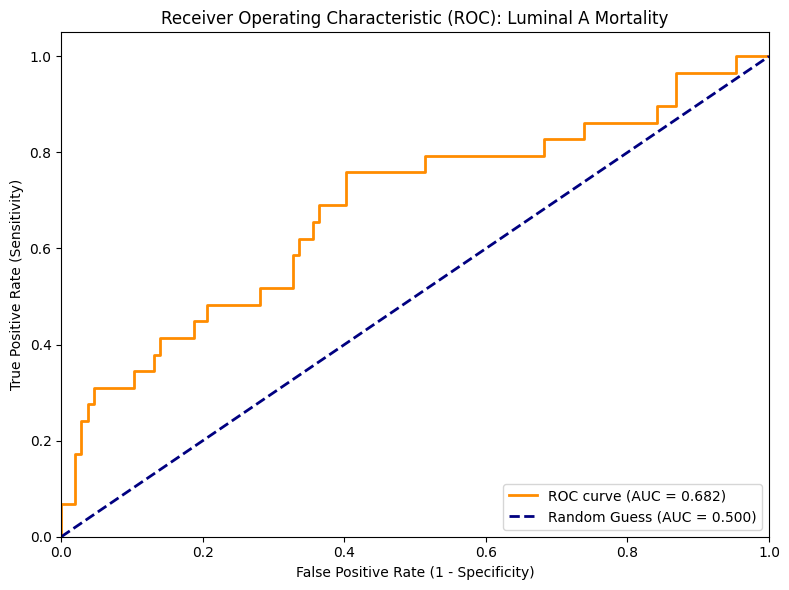

In [18]:
test_proba = winning_model.predict_proba(X_test_scaled)[:, 1]

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, test_proba)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {best_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC): Luminal A Mortality')
plt.legend(loc="lower right")
plt.tight_layout()
#plt.savefig("ROC_Curve_LumA.pdf", format='pdf', dpi=300)
plt.show()

In [19]:
# Threshold Moving & Calibration Plot

test_proba = winning_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, test_proba)

# Youden's J (J = TPR - FPR)
youden_j = tpr - fpr
best_threshold_index = np.argmax(youden_j)
best_thresh = thresholds[best_threshold_index]

print("Default threshold equals to 0.500")
print(f"The optimal threshold tuned based on ROC curve equals to  {best_thresh:.3f}\n")

y_pred_custom = (test_proba >= best_thresh).astype(int)

print(f"Classification Report (with optimal Threshold = {best_thresh:.3f}):")
print(classification_report(y_test, y_pred_custom))

test_auc_custom = roc_auc_score(y_test, y_pred_custom)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_custom)

print(f"\n\n🏆 Threshold tuned model: Test AUC: {test_auc_custom:.3f}, Test Bal Acc: {test_bal_acc:.3f}")

Default threshold equals to 0.500
The optimal threshold tuned based on ROC curve equals to  0.429

Classification Report (with optimal Threshold = 0.429):
              precision    recall  f1-score   support

           0       0.90      0.60      0.72       107
           1       0.34      0.76      0.47        29

    accuracy                           0.63       136
   macro avg       0.62      0.68      0.59       136
weighted avg       0.78      0.63      0.67       136



🏆 Threshold tuned model: Test AUC: 0.678, Test Bal Acc: 0.678


In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.show()

NameError: name 'y_pred' is not defined

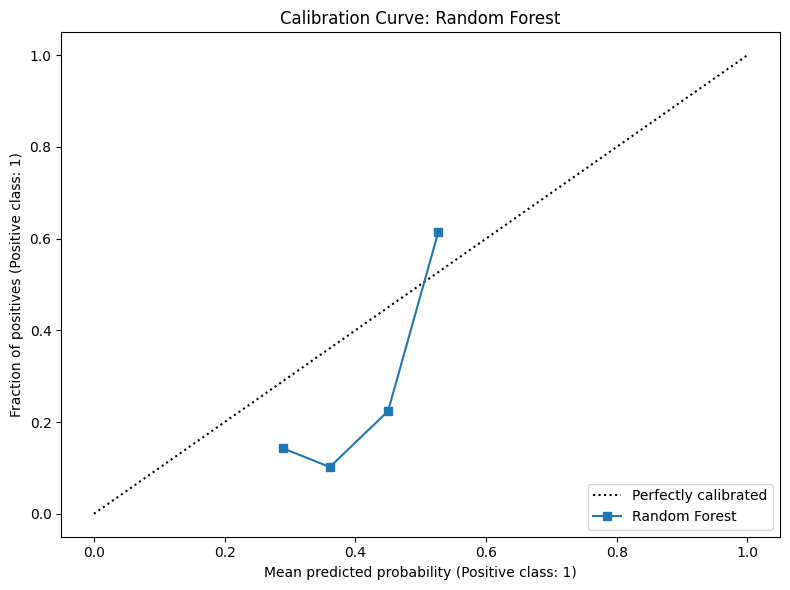

In [ ]:
plt.figure(figsize=(8, 6))
CalibrationDisplay.from_estimator(
    winning_model,
    X_test_scaled,
    y_test,
    n_bins=10,
    name=winning_model_name,
    ax=plt.gca()
)
plt.title(f"Calibration Curve: {winning_model_name}")
plt.tight_layout()
#plt.savefig("Calibration_Curve_LumA.pdf", format='pdf', dpi=300)
plt.show()

## Incremental Feature Gain Analysis (Forward Feature Evaluation)

In [ ]:
# Extract and sort the feature importances from the winning Random Forest
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': winning_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_5_features = feature_importances['Feature'].head(5).tolist()

In [ ]:
# CLINICAL VALUE ADDITION TABLE (Baseline Assumption: Genomic PAM50 Status (Luminal A) = 'Low Risk)

In [ ]:
incremental_features = []
previous_auc = 0.500
auc_scores = [previous_auc]
gain_scores = [0.0]
feature_labels = ['PAM50\n(Baseline)']

# Loop through the top 5 features, adding them one by one
for i, feature in enumerate(top_5_features):
    incremental_features.append(feature)

    X_train_subset = X_train_scaled[incremental_features]
    X_test_subset = X_test_scaled[incremental_features]

    mini_rf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
    mini_rf.fit(X_train_subset, y_train)

    mini_proba = mini_rf.predict_proba(X_test_subset)[:, 1]
    current_auc = roc_auc_score(y_test, mini_proba)
    gain = current_auc - previous_auc

    # Store for plotting
    auc_scores.append(current_auc)
    gain_scores.append(gain)
    feature_labels.append(f"+ {feature}")

    previous_auc = current_auc

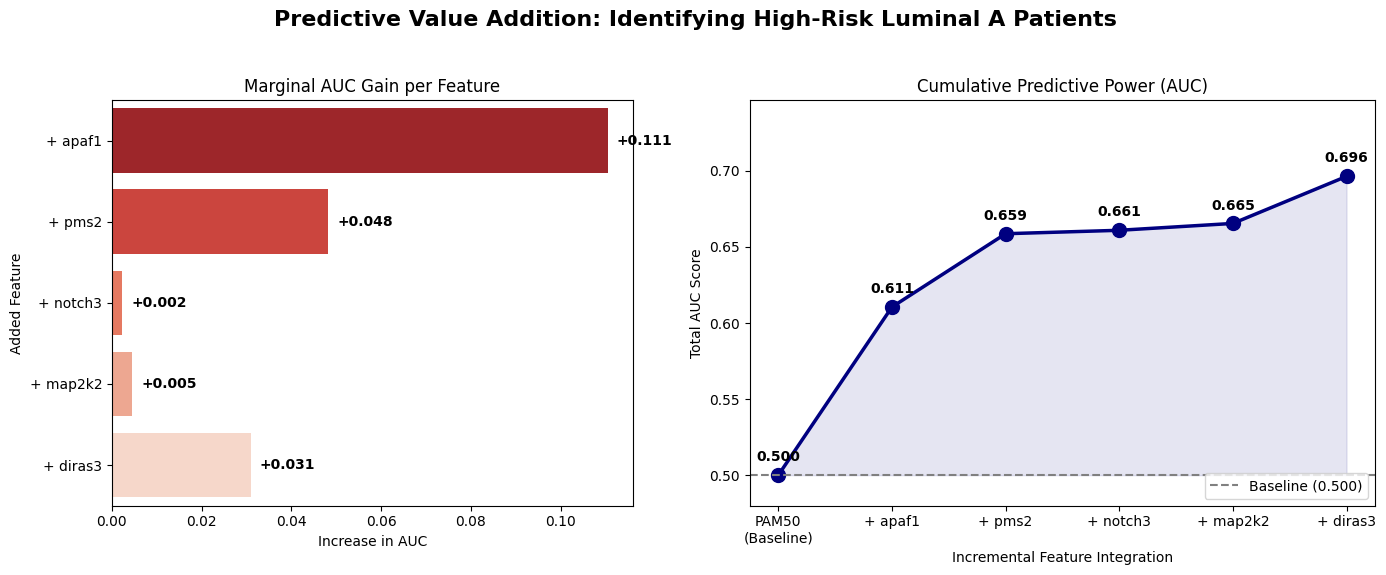

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle("Predictive Value Addition: Identifying High-Risk Luminal A Patients", fontsize=16, fontweight='bold')

# Horizontal Bar Chart of Marginal Gains
sns.barplot(x=gain_scores[1:], y=feature_labels[1:], ax=ax1, palette="Reds_r")
ax1.set_title("Marginal AUC Gain per Feature", fontsize=12)
ax1.set_xlabel("Increase in AUC")
ax1.set_ylabel("Added Feature")
for i, v in enumerate(gain_scores[1:]):
    ax1.text(v + 0.002, i, f"+{v:.3f}", color='black', va='center', fontweight='bold')

# Line Plot of Cumulative AUC
ax2.plot(feature_labels, auc_scores, marker='o', markersize=10, linestyle='-', color='navy', linewidth=2.5)
ax2.fill_between(feature_labels, 0.500, auc_scores, color='navy', alpha=0.1)
ax2.axhline(y=0.500, color='gray', linestyle='--', label='Baseline (0.500)')
ax2.set_title("Cumulative Predictive Power (AUC)", fontsize=12)
ax2.set_xlabel("Incremental Feature Integration")
ax2.set_ylabel("Total AUC Score")
ax2.set_ylim(0.48, max(auc_scores) + 0.05)
ax2.legend(loc="lower right")

# Annotate the line chart points
for i, txt in enumerate(auc_scores):
    ax2.annotate(f"{txt:.3f}", (feature_labels[i], auc_scores[i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#plt.savefig("Clinical_Value_Addition_Dashboard.pdf", format='pdf', dpi=300)
plt.show()

## Explainable AI (Shapley values)

In [ ]:
# TreeExplainer calculates the exact marginal contribution of every clinical feature.

explainer = shap.TreeExplainer(winning_model)
shap_values = explainer.shap_values(X_test_scaled)
shap_values.shape

(136, 500, 2)

In [ ]:
# For binary classification in Random Forest, shap_values is a list.
# Index 1 is the explanation for the positive class (target_mortality = 1).

shap_values_disease_death = shap_values[1] if isinstance(shap_values, list) else shap_values
shap_values_disease_death.shape

(136, 500, 2)

In [ ]:
shap_values_death = shap_values[:,:,1]
shap_values_death.shape

(136, 500)

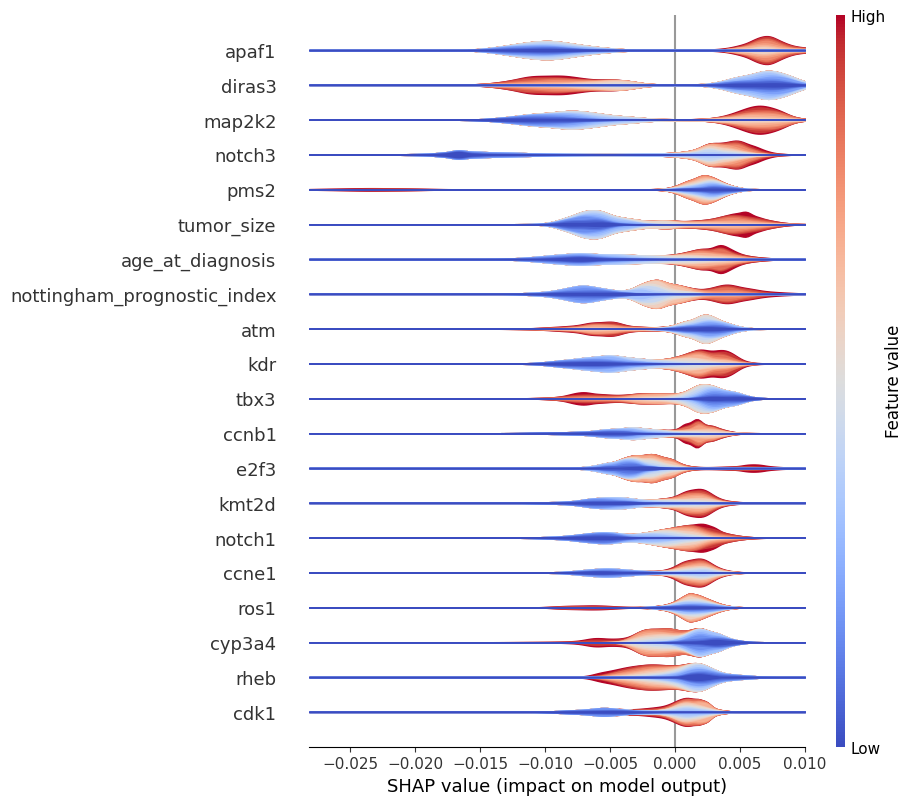

In [ ]:
# Layered violin plot explanation: https://shap.readthedocs.io/en/stable/example_notebooks/api_examples/plots/violin.html

shap.plots.violin(shap_values_death, features=X_test_scaled,
                   feature_names=features, plot_type="layered_violin")


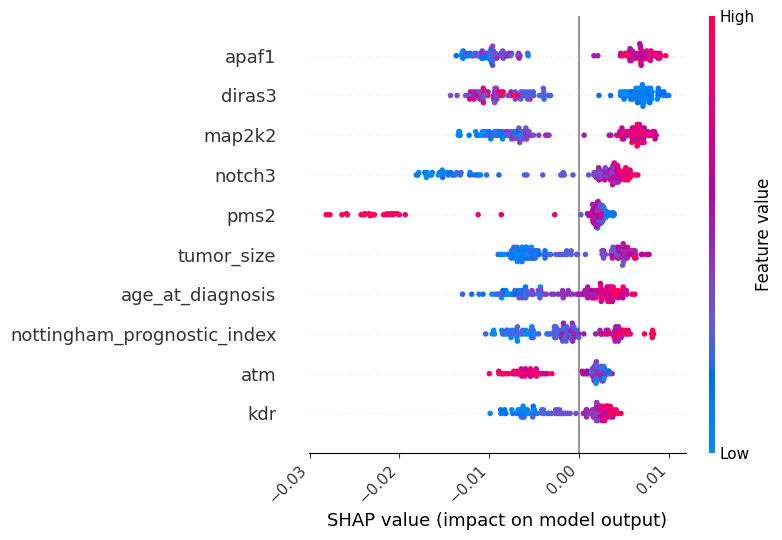

In [ ]:
"""
Plot the top 10 most important features
Each dot is a patient.
Red dots = high feature value (e.g., high NPI). Blue dots = low feature value.
Dots pushed to the right mean that feature increased the risk of death.
"""

shap.summary_plot(shap_values_death,
                    X_test_scaled,
                    feature_names=features, 
                    max_display=10,
                    show=False)


plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()